# Outlier visualization — **after filtering cofactor-bound FPs**

We first drop every sample whose FPbase `cofactor` field is non-empty (biliverdin / flavin / bilirubin /
phycocyanobilin / riboflavin-lumazine) — these are a *different regime* (peak set by a bound chromophore, not a
GFP-type autocatalytic one). That leaves the **canonical autocatalytic FPs**.

The remaining **four** criteria (cofactor is now vacuous) are then **recomputed within the filtered set** — the
z-score MADs, the nearest-neighbor similarities, and the embedding manifold all shift once the cofactor cluster
is gone, so this surfaces the *next* tier of outliers:

1. **Peak-label** — `ex_max`, `em_max`, Stokes (`em−ex`), modified z |z|>3.5
2. **Sequence isolation** — nearest-neighbor 4-mer cosine similarity (< 0.10)
3. **Embedding anomaly** — IsolationForest on PCA of mean-pooled ESM-2 (5% contamination)
4. **Length** — modified z on sequence length (|z|>3.5)

The kept-row index is saved to `training_data/canonical/keep_index.npy` (+ a filtered assignments CSV) so the
same filter can be applied for retraining.

## 0. Filter cofactor + recompute the four criteria on the canonical subset

In [1]:
import csv, json, os, numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity as cossim
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC=True
except Exception: HAVE_APC=False
import matplotlib.pyplot as plt
class _C:
    def __getattr__(self,k): return getattr(apc,k) if HAVE_APC else {"aegean":"#2b6c8f","amber":"#f6a200","rose":"#c5474b","seaweed":"#3b8a6e","gray":"#9a9a9a","wish":"#5088c5","aster":"#7a5ea8","dragon":"#b23b3b","lime":"#97c800","tangerine":"#ff8c42"}.get(k,"#333")
C=_C()
TD="training_data"
allrows=list(csv.DictReader(open(f"{TD}/peak_assignments.csv"))); Nall=len(allrows)
peaks_all=np.load(f"{TD}/peaks.npy").astype(np.float32)
slug_all=[r["slug"] for r in allrows]
prot=json.load(open("../fpbase-extractor/fpbase_output/fpbase_proteins.json"))
cofmap={p["slug"]:(p.get("cofactor") or "") for p in prot}
COFall=np.array([cofmap.get(s,"") for s in slug_all])

# ---- FILTER: keep standard autocatalytic chromophore (cofactor field empty) ----
keep=np.where(np.array([c.strip().lower() in ("","none") for c in COFall]))[0]
os.makedirs(f"{TD}/canonical",exist_ok=True)
np.save(f"{TD}/canonical/keep_index.npy", keep)
with open(f"{TD}/canonical/peak_assignments.csv","w",newline="") as fh:
    w=csv.DictWriter(fh,fieldnames=list(allrows[0].keys())); w.writeheader(); [w.writerow(allrows[i]) for i in keep]
print(f"filtered cofactor-bound: kept {len(keep)} / {Nall} canonical FPs (dropped {Nall-len(keep)})")

# subset everything to the canonical set
rows=[allrows[i] for i in keep]; N=len(rows)
peaks=peaks_all[keep]; EX=peaks[:,0]; EM=peaks[:,1]; STK=EM-EX
names=[r["name"] for r in rows]; LEN=np.array([int(r["seq_len"]) for r in rows])
SW=np.array([(r.get("switch_type") or "basic") for r in rows])
seqsA=[None]*Nall; h=None
for line in open(f"{TD}/sequences.fasta"):
    line=line.strip()
    if line.startswith(">"): h=int(line[1:].split("|")[0])
    elif line: seqsA[h]=line
seqs=[seqsA[i] for i in keep]
Hh=np.load(f"{TD}/esm_residue_fp16.npy"); Ls=np.load(f"{TD}/esm_residue_len.npy")
emb=np.stack([Hh[i,:Ls[i]].astype(np.float32).mean(0) for i in keep])

def mz(x):
    med=np.median(x); mad=np.median(np.abs(x-med)) or 1e-9; return 0.6745*(x-med)/mad
z_ex,z_em,z_st,z_len=mz(EX),mz(EM),mz(STK),mz(LEN)
# recomputed within the filtered set
f_peak=(np.abs(z_ex)>3.5)|(np.abs(z_em)>3.5)|(np.abs(z_st)>3.5)
Xk=CountVectorizer(analyzer="char",ngram_range=(4,4)).fit_transform(seqs)
Sk=cossim(Xk); np.fill_diagonal(Sk,-1); NN=Sk.max(1); f_seq=NN<0.10
Zpca=PCA(50,random_state=0).fit_transform((emb-emb.mean(0))/(emb.std(0)+1e-6))
iso=IsolationForest(contamination=0.05,random_state=0).fit(Zpca)
ISO=-iso.score_samples(Zpca); f_emb=iso.predict(Zpca)==-1
f_len=np.abs(z_len)>3.5
CRIT=["peak","seq-iso","embed","length"]
FLAGS=np.stack([f_peak,f_seq,f_emb,f_len]).T.astype(int); NCRIT=FLAGS.sum(1)
TSNE2=TSNE(2,random_state=0,perplexity=30,init="pca").fit_transform(Zpca)
# categorical colors for switch_type
swc=[ "basic","photoactivatable","photoswitchable","photoconvertible","timer","multistate"]
PAL=[C.gray,C.aegean,C.amber,C.rose,C.seaweed,C.aster]
SWCOL={s:PAL[i%len(PAL)] for i,s in enumerate(sorted(set(SW)))}
print(f"canonical N={N} | flagged >=1: {(NCRIT>=1).sum()}  >=2: {(NCRIT>=2).sum()}  >=3: {(NCRIT>=3).sum()}")
print("per-criterion (recomputed):", {c:int(FLAGS[:,j].sum()) for j,c in enumerate(CRIT)})
print("switch_type values:", {s:int((SW==s).sum()) for s in sorted(set(SW))})

filtered cofactor-bound: kept 835 / 894 canonical FPs (dropped 59)


canonical N=835 | flagged >=1: 227  >=2: 26  >=3: 10
per-criterion (recomputed): {'peak': 188, 'seq-iso': 5, 'embed': 42, 'length': 31}
switch_type values: {'basic': 685, 'multistate': 16, 'other': 12, 'photoactivatable': 11, 'photoconvertible': 68, 'photoswitchable': 40, 't': 3}


## 1. Peak-label criterion — spectral landscape (canonical FPs)

`ex_max` vs `em_max`, colored by `switch_type`; peak-flagged points ringed. Marginal histograms with the
recomputed |z|>3.5 thresholds. With the far-red cofactor proteins gone, the panel is dominated by the
green/red autocatalytic FP continuum.

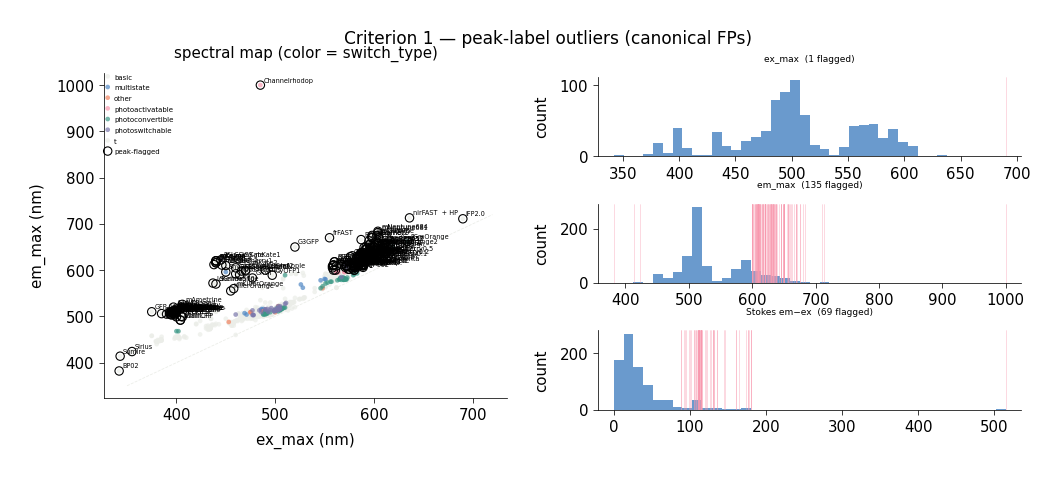

In [2]:
fig=plt.figure(figsize=(14,5.5))
ax=fig.add_axes([0.06,0.1,0.40,0.82])
for s in sorted(set(SW)):
    m=SW==s
    if m.any(): ax.scatter(EX[m],EM[m],s=22,c=SWCOL[s],alpha=0.7,edgecolor="none",label=s)
ax.scatter(EX[f_peak],EM[f_peak],s=70,facecolors="none",edgecolors="k",lw=1.1,label="peak-flagged")
lo,hi=350,720; ax.plot([lo,hi],[lo,hi],ls="--",c=C.gray,lw=0.8)
for i in np.where(f_peak)[0]: ax.annotate(names[i][:13],(EX[i],EM[i]),fontsize=6.5,xytext=(3,3),textcoords="offset points")
ax.set_xlabel("ex_max (nm)"); ax.set_ylabel("em_max (nm)"); ax.set_title("spectral map (color = switch_type)"); ax.legend(fontsize=7,loc="upper left")
for k,(arr,lab) in enumerate([(EX,"ex_max"),(EM,"em_max"),(STK,"Stokes em−ex")]):
    a=fig.add_axes([0.55,0.71-0.32*k,0.42,0.20])
    a.hist(arr,bins=40,color=C.aegean,alpha=0.85)
    z=mz(arr)
    for v in arr[np.abs(z)>3.5]: a.axvline(v,color=C.rose,lw=0.6,alpha=0.6)
    a.set_ylabel("count"); a.set_title(f"{lab}  ({int(np.sum(np.abs(z)>3.5))} flagged)",fontsize=9)
plt.suptitle("Criterion 1 — peak-label outliers (canonical FPs)",y=1.03); plt.show()

## 2. Sequence-isolation criterion (recomputed within canonical set)

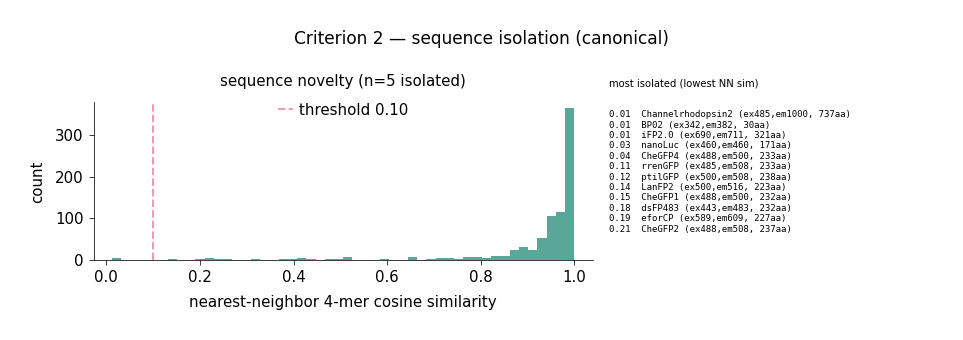

In [3]:
fig,ax=plt.subplots(1,2,figsize=(13,4.2),gridspec_kw={"width_ratios":[2,1.3]})
ax[0].hist(NN,bins=50,color=C.seaweed,alpha=0.85); ax[0].axvline(0.10,color=C.rose,ls="--",label="threshold 0.10")
ax[0].set_xlabel("nearest-neighbor 4-mer cosine similarity"); ax[0].set_ylabel("count")
ax[0].set_title(f"sequence novelty (n={int(f_seq.sum())} isolated)"); ax[0].legend()
ax[1].axis("off"); ax[1].set_title("most isolated (lowest NN sim)",fontsize=10,loc="left")
iso_idx=np.argsort(NN)[:12]
txt="\n".join(f"{NN[i]:.2f}  {names[i][:26]} (ex{EX[i]:.0f},em{EM[i]:.0f}, {LEN[i]}aa)" for i in iso_idx)
ax[1].text(0,0.95,txt,va="top",ha="left",fontsize=9,family="monospace")
plt.suptitle("Criterion 2 — sequence isolation (canonical)"); plt.tight_layout(); plt.show()

## 3. Embedding-anomaly criterion (t-SNE recomputed on canonical embeddings)

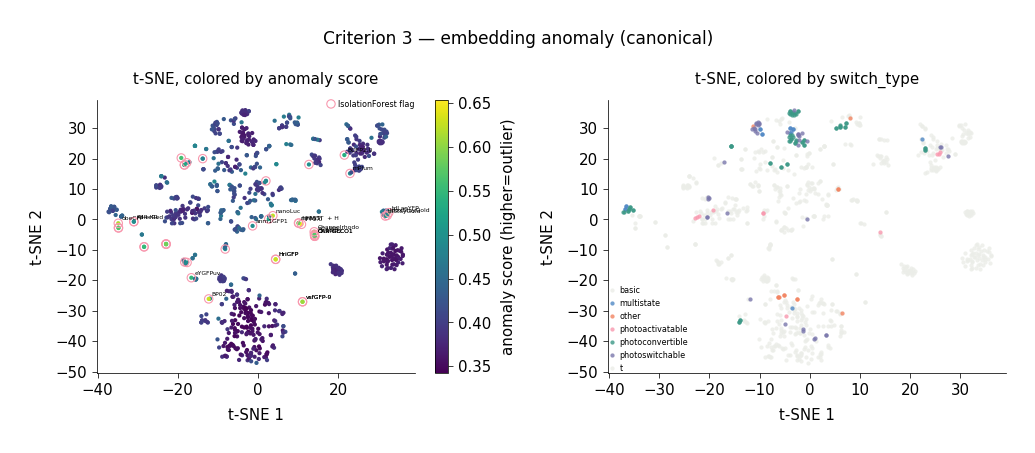

In [4]:
fig,ax=plt.subplots(1,2,figsize=(14,5.8))
sc=ax[0].scatter(TSNE2[:,0],TSNE2[:,1],c=ISO,s=18,cmap="viridis")
ax[0].scatter(TSNE2[f_emb,0],TSNE2[f_emb,1],s=70,facecolors="none",edgecolors=C.rose,lw=1.1,label="IsolationForest flag")
for i in np.where(f_emb&(NCRIT>=2))[0]: ax[0].annotate(names[i][:12],(TSNE2[i,0],TSNE2[i,1]),fontsize=6,xytext=(3,3),textcoords="offset points")
fig.colorbar(sc,ax=ax[0],label="anomaly score (higher=outlier)"); ax[0].set_title("t-SNE, colored by anomaly score"); ax[0].legend(fontsize=8)
for s in sorted(set(SW)):
    m=SW==s
    if m.any(): ax[1].scatter(TSNE2[m,0],TSNE2[m,1],s=18,c=SWCOL[s],alpha=0.8,label=s)
ax[1].set_title("t-SNE, colored by switch_type"); ax[1].legend(fontsize=8)
for a in ax: a.set_xlabel("t-SNE 1"); a.set_ylabel("t-SNE 2")
plt.suptitle("Criterion 3 — embedding anomaly (canonical)"); plt.tight_layout(); plt.show()

## 4. Length criterion (recomputed)

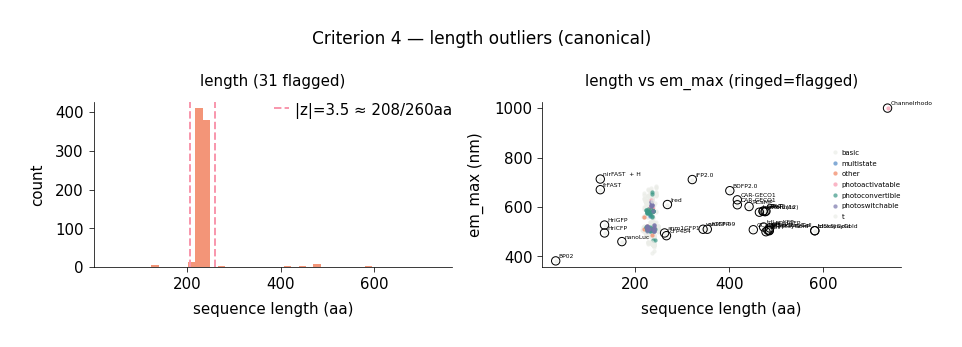

In [5]:
fig,ax=plt.subplots(1,2,figsize=(13,4.3))
ax[0].hist(LEN,bins=45,color=C.amber,alpha=0.85)
thi=np.median(LEN)+(3.5/0.6745)*(np.median(np.abs(LEN-np.median(LEN))) or 1)
tlo=np.median(LEN)-(3.5/0.6745)*(np.median(np.abs(LEN-np.median(LEN))) or 1)
ax[0].axvline(thi,color=C.rose,ls="--",label=f"|z|=3.5 ≈ {tlo:.0f}/{thi:.0f}aa"); ax[0].axvline(tlo,color=C.rose,ls="--")
ax[0].set_xlabel("sequence length (aa)"); ax[0].set_ylabel("count"); ax[0].set_title(f"length ({int(f_len.sum())} flagged)"); ax[0].legend()
for s in sorted(set(SW)):
    m=SW==s
    if m.any(): ax[1].scatter(LEN[m],EM[m],s=18,c=SWCOL[s],alpha=0.7,label=s)
ax[1].scatter(LEN[f_len],EM[f_len],s=70,facecolors="none",edgecolors="k",lw=1.0)
for i in np.where(f_len)[0]: ax[1].annotate(names[i][:12],(LEN[i],EM[i]),fontsize=6,xytext=(3,3),textcoords="offset points")
ax[1].set_xlabel("sequence length (aa)"); ax[1].set_ylabel("em_max (nm)"); ax[1].set_title("length vs em_max (ringed=flagged)"); ax[1].legend(fontsize=7)
plt.suptitle("Criterion 4 — length outliers (canonical)"); plt.tight_layout(); plt.show()

## 5. Consensus across the four remaining criteria

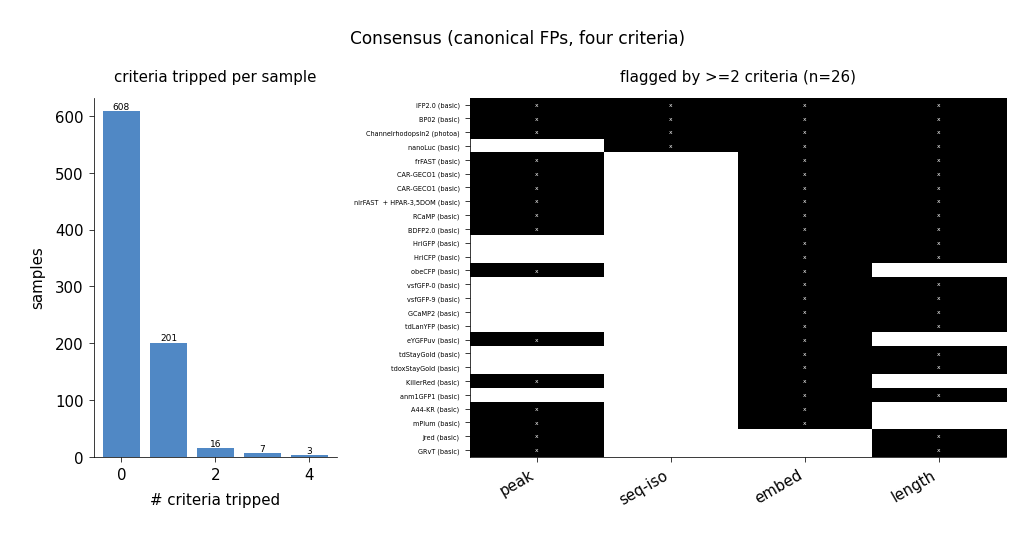

name                                      sw   ex   em  stk  len    NN   iso  criteria
iFP2.0                                 basic  690  711   21  321  0.01  0.65  peak,seq-iso,embed,length
BP02                                   basic  342  382   40   30  0.01  0.63  peak,seq-iso,embed,length
Channelrhodopsin2           photoactivatable  485 1000  515  737  0.01  0.61  peak,seq-iso,embed,length
nanoLuc                                basic  460  460    0  171  0.03  0.62  seq-iso,embed,length
frFAST                                 basic  555  670  115  125  0.72  0.59  peak,embed,length
CAR-GECO1                              basic  576  629   53  417  1.00  0.59  peak,embed,length
CAR-GECO1                              basic  562  609   47  417  1.00  0.59  peak,embed,length
nirFAST  + HPAR-3,5DOM                 basic  636  713   77  125  0.72  0.58  peak,embed,length
RCaMP                                  basic  575  602   27  442  0.66  0.57  peak,embed,length
BDFP2.0               

In [6]:
fig,ax=plt.subplots(1,2,figsize=(14,7),gridspec_kw={"width_ratios":[1,2.2]})
vals,c=np.unique(NCRIT,return_counts=True)
ax[0].bar(vals,c,color=C.aegean); ax[0].set_xlabel("# criteria tripped"); ax[0].set_ylabel("samples")
for v,cc in zip(vals,c): ax[0].text(v,cc,str(cc),ha="center",va="bottom",fontsize=9)
ax[0].set_title("criteria tripped per sample")
sel=np.where(NCRIT>=2)[0]; sel=sel[np.argsort(-(NCRIT[sel]*10+ISO[sel]))]
if len(sel):
    ax[1].imshow(FLAGS[sel],aspect="auto",cmap="Greys",vmin=0,vmax=1)
    ax[1].set_xticks(range(4)); ax[1].set_xticklabels(CRIT,rotation=30,ha="right")
    ax[1].set_yticks(range(len(sel))); ax[1].set_yticklabels([f"{names[i][:26]} ({SW[i][:6]})" for i in sel],fontsize=6.5)
    ax[1].set_title(f"flagged by >=2 criteria (n={len(sel)})")
    for (yy,xx),v in np.ndenumerate(FLAGS[sel]):
        if v: ax[1].text(xx,yy,"x",ha="center",va="center",color="white",fontsize=6)
else:
    ax[1].axis("off"); ax[1].text(0.5,0.5,"no sample trips >=2 criteria",ha="center")
plt.suptitle("Consensus (canonical FPs, four criteria)"); plt.tight_layout(); plt.show()

print(f"{'name':28s}{'sw':>16}{'ex':>5}{'em':>5}{'stk':>5}{'len':>5}{'NN':>6}{'iso':>6}  criteria")
for i in (sel if len(sel) else np.argsort(-NCRIT)[:15]):
    tags=",".join(CRIT[j] for j in range(4) if FLAGS[i,j])
    print(f"{names[i][:28]:28s}{SW[i][:16]:>16}{EX[i]:5.0f}{EM[i]:5.0f}{STK[i]:5.0f}{LEN[i]:5d}{NN[i]:6.2f}{ISO[i]:6.2f}  {tags}")

## Notes
- Filter = FPbase `cofactor` empty (canonical autocatalytic chromophore). Saved index:
  `training_data/canonical/keep_index.npy` (apply to the aligned `peaks.npy` / embedding cache to retrain on
  canonical-only).
- All four criteria are **recomputed within the filtered set**, so thresholds and the embedding manifold reflect
  only canonical FPs — this is what surfaces the residual outliers rather than the (now-removed) cofactor cluster.
- Compare with `outlier_visualization.ipynb` (the full 894-sample version including the cofactor criterion).